# Homework Answer

* Họ và tên: Nguyễn Vạn Phúc Huy 
* MSSV: 23110163

- 1. Choose an image from the Internet

  * Load or download an image from the Internet.

- 2. Perform the following operations on the image:
  * Read and display the original image
  * Scale (resize) the image (zoom in / zoom out)
  * Rotate the image by a given angle (30,45,60 (3 images))
  * Translate (shift) the image by some pixels
  * Apply an Affine Transformation
  * Zoom with Cropping
    * When zooming into an image, parts of the image may go beyond the frame.
    * Write code to crop the central region of the zoomed image so that the output size remains the same as the original image.
    * Hint: Use array slicing or **cv2.resize()** after applying the zoom transformation.
  * Save each transformed image with descriptive names

- 3. Advanced Image Transformation Tasks
  * Rotate around an arbitrary point
    * Write a function to rotate an image around a specific point (not the image center).

  * Combine Translation + Rotation
    * Apply a translation (shift) first, then rotate the image.
    * Reverse the order (rotate first, then translate) and compare the results.
    * Observe how the transformation order affects the final image.

  * Inverse Transformation
    * Given an image that has been rotated by 45° and translated 50px to the right,
    * Write a function to restore the original image by applying the inverse transformation.

  * Affine Transform for Data Augmentation
    * Generate 10 distinct augmented versions of the same image using combinations of affine transformations, including:
      * Rotation: randomly within ±10°
      * Scaling (Zoom): randomly zoom in or out by 10–20%
      * Translation: randomly shift the image by ±10 pixels along both x and y axes
      * (Optional) Combine multiple transformations in a single augmentation step to simulate real-world variations.
    * Save and display all augmented images.

  * Image Alignment (Image Registration)
    * Suppose you have two images of the same object but taken at slightly different angles.
    * Find the affine transformation matrix that aligns (registers) the two images.
    * Hint: Use the OpenCV function cv2.estimateAffinePartial2D().

- 4. Apply transformations to each color channel separately (R, G, B).
  * How do slight differences in rotation/scaling per channel affect the reconstructed RGB image?
  * Can this technique simulate color aberration seen in old cameras?

- 5.Report
  * Present the original image alongside all transformed images in a comparative layout.
  * Discuss how different transformations affect image geometry and potential implications for data augmentation or model training.

## 1. Choose an image from the Internet

Import Libs

In [107]:
import cv2 
import pandas as pd
import numpy as np
import random as rng
from cv2 import imwrite, imread
from matplotlib import pyplot as plt    

Getting image

In [108]:
# Local
newImg = imread('the end.png')

# Online
# !gdown 1nlnqmg_br8e4UEDFnWeem6XqqD3Wgoos
# img_path = "/content/the end.png"
# newImg = imread(img_path)

## 2. Perform the following operations on the image:
  * Read and display the original image
  * Scale (resize) the image (zoom in / zoom out)
  * Rotate the image by a given angle (30,45,60 (3 images))
  * Translate (shift) the image by some pixels
  * Apply an Affine Transformation
  * Zoom with Cropping
    * When zooming into an image, parts of the image may go beyond the frame.
    * Write code to crop the central region of the zoomed image so that the output size remains the same as the original image.
    * Hint: Use array slicing or **cv2.resize()** after applying the zoom transformation.
  * Save each transformed image with descriptive names

Read and Display the original image

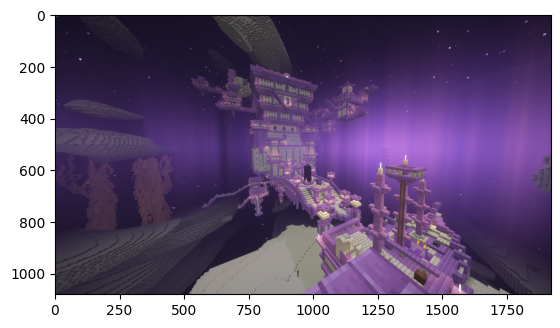

In [109]:
# read image

# local 
newImg = imread('the end.png')
newImg = cv2.cvtColor(newImg, cv2.COLOR_BGR2RGB)

# online
# newImg = imread(img_path)

# display image
plt.imshow(newImg)


Scale (resize) the image (zoom in / zoom out)

In [110]:
def resizeImage(image, widthScale, heightScale):
    scaledImgDim = (int(image.shape[1] * widthScale), int(image.shape[0] * heightScale))
    moddedImage = cv2.resize(image, scaledImgDim, interpolation = cv2.INTER_CUBIC)
    return moddedImage


# zoom in x2
zoomedInImg = resizeImage(newImg, 2, 2)

# zoom out x0.5
zoomedOutImg = resizeImage(newImg, 0.5, 0.5)

Rotate the image by a given angle (30,45,60 (3 images))

In [111]:
def rotateImage(image, angle, anchorPoint=None):
    if anchorPoint is None:
        imageRotatePoint = (image.shape[1]//2, image.shape[0]//2)
    else:
        imageRotatePoint = anchorPoint
    rotMat = cv2.getRotationMatrix2D(imageRotatePoint, angle, 1.0)
    rotatedImage = cv2.warpAffine(image, rotMat, (image.shape[1], image.shape[0])) # Width, Height :skull:
    return rotatedImage

# rotate 30
rotatedImg30 = rotateImage(newImg, 30)
# rotate 45
rotatedImg45 = rotateImage(newImg, 45)
# rotate 60
rotatedImg60 = rotateImage(newImg, 60)

Translate (shift) the image by some pixels

In [112]:
def translateImage(image, x, y):
    transMat = np.float32([[1, 0, x], [0, 1, y]])
    translatedImage = cv2.warpAffine(image, transMat, (image.shape[1], image.shape[0]))
    return translatedImage

translatedImg = translateImage(newImg, 100, 50)



Apply an Affine Transformation

In [113]:
def affineTransform(image, originalPoints, transformedPoints):
    affineMat = cv2.getAffineTransform(np.float32(originalPoints), np.float32(transformedPoints))
    affineTransformedImage = cv2.warpAffine(image, affineMat, (image.shape[1], image.shape[0]))
    return affineTransformedImage

originalPoints = [[50, 50], [200, 50], [50, 200]]
transformedPoints = [[70, 100], [220, 50], [100, 250]]
affinedImg = affineTransform(newImg, originalPoints, transformedPoints)


Zoom with Cropping
* When zooming into an image, parts of the image may go beyond the frame.
* Write code to crop the central region of the zoomed image so that the output size remains the same as the original image.
* Hint: Use array slicing or **cv2.resize()** after applying the zoom transformation.

In [114]:
def cropCenter(image, targetWidth, targetHeight):
    centerX, centerY = image.shape[1] // 2, image.shape[0] // 2
    halfWidth, halfHeight = targetWidth // 2, targetHeight // 2
    
    startX = max(centerX - halfWidth, 0)
    startY = max(centerY - halfHeight, 0)
    endX = startX + targetWidth
    endY = startY + targetHeight
    
    croppedImage = image[startY:endY, startX:endX]
    return croppedImage

def zoomWithCropping(image, zoomMult):
    zoomedImage = resizeImage(image, zoomMult, zoomMult)
    return cropCenter(zoomedImage, image.shape[1], image.shape[0])
#zoom x2 and crop
zoomedCroppedImg = zoomWithCropping(newImg, 2)

Save each transformed image with descriptive names


In [115]:
# Convert from brg to rgb for importing image
zoomedInImg = cv2.cvtColor(zoomedInImg, cv2.COLOR_RGB2BGR)
zoomedOutImg = cv2.cvtColor(zoomedOutImg, cv2.COLOR_RGB2BGR)
rotatedImg30 = cv2.cvtColor(rotatedImg30, cv2.COLOR_RGB2BGR)
rotatedImg45 = cv2.cvtColor(rotatedImg45, cv2.COLOR_RGB2BGR)
rotatedImg60 = cv2.cvtColor(rotatedImg60, cv2.COLOR_RGB2BGR)
translatedImg = cv2.cvtColor(translatedImg, cv2.COLOR_RGB2BGR)
affinedImg = cv2.cvtColor(affinedImg, cv2.COLOR_RGB2BGR)
zoomedCroppedImg = cv2.cvtColor(zoomedCroppedImg, cv2.COLOR_RGB2BGR)

# save images
imwrite('zoomed_in_x2.png', zoomedInImg)
imwrite('zoomed_out_x0.5.png', zoomedOutImg)
imwrite('rotated_30_degree.png', rotatedImg30)
imwrite('rotated_45_degree.png', rotatedImg45)
imwrite('rotated_60_degree.png', rotatedImg60)
imwrite('translated_100_50.png', translatedImg)
imwrite('affined_image.png', affinedImg)
imwrite('zoomed_cropped_x2.png', zoomedCroppedImg)


True

## 3. Advanced Image Transformation Tasks
  * Rotate around an arbitrary point
    * Write a function to rotate an image around a specific point (not the image center).

  * Combine Translation + Rotation
    * Apply a translation (shift) first, then rotate the image.
    * Reverse the order (rotate first, then translate) and compare the results.
    * Observe how the transformation order affects the final image.

  * Inverse Transformation
    * Given an image that has been rotated by 45° and translated 50px to the right,
    * Write a function to restore the original image by applying the inverse transformation.

  * Affine Transform for Data Augmentation
    * Generate 10 distinct augmented versions of the same image using combinations of affine transformations, including:
      * Rotation: randomly within ±10°
      * Scaling (Zoom): randomly zoom in or out by 10–20%
      * Translation: randomly shift the image by ±10 pixels along both x and y axes
      * (Optional) Combine multiple transformations in a single augmentation step to simulate real-world variations.
    * Save and display all augmented images.

  * Image Alignment (Image Registration)
    * Suppose you have two images of the same object but taken at slightly different angles.
    * Find the affine transformation matrix that aligns (registers) the two images.
    * Hint: Use the OpenCV function cv2.estimateAffinePartial2D().


Rotate around an arbitrary point
* Write a function to rotate an image around a specific point (not the image center).


In [116]:
# Already done it as above from the rotateImage function with the point is the anchorPoint 
# def rotateImage(image, angle, anchorPoint=None)

#rotate 15 degree with anchor point at top left corner
rotatedImg15Anchored = rotateImage(newImg, 15, anchorPoint=(0, 0))

Combine Translation + Rotation
* Apply a translation (shift) first, then rotate the image.
* Reverse the order (rotate first, then translate) and compare the results.
* Observe how the transformation order affects the final image.


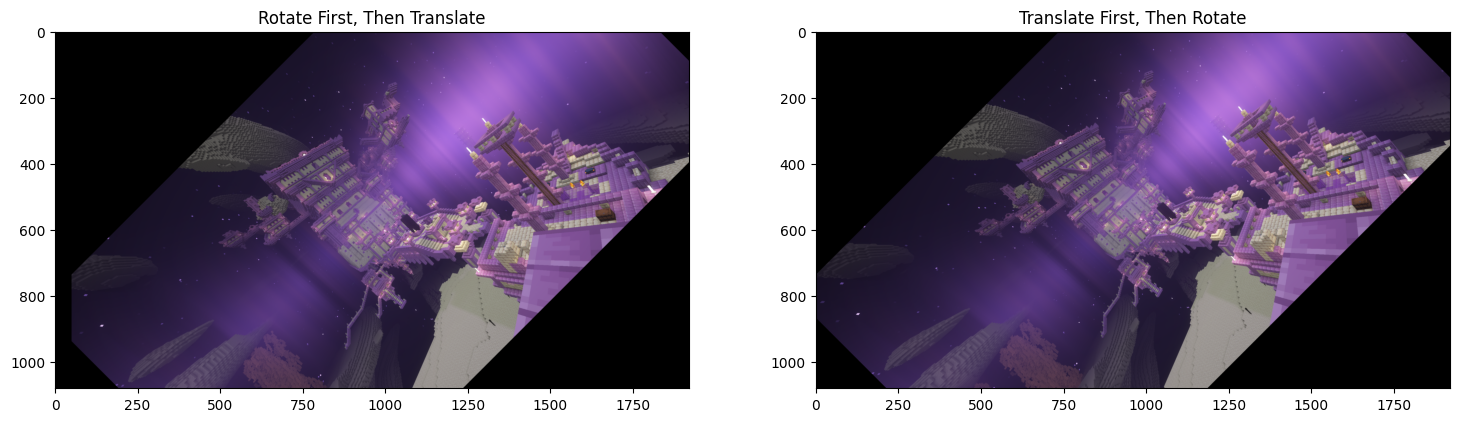

In [117]:
# rotated first, then translated
newTestImgRT = rotateImage(newImg, 45)
newTestImgRT = translateImage(newTestImgRT, 50, 0)
# translated first, then rotated
newTestImgTR = translateImage(newImg, 50, 0)
newTestImgTR = rotateImage(newTestImgTR, 45)

# Display both images
plt.figure(figsize=(18,6))
plt.subplot(1,2,1)
plt.title("Rotate First, Then Translate")
plt.imshow(newTestImgRT)
plt.subplot(1,2,2)
plt.title("Translate First, Then Rotate")
plt.imshow(newTestImgTR)
plt.show()




In [118]:
# Observe how the transformation order affects the final image and compare the results.

# Ở tấm ảnh bên trái (rotate first, then translate), ta thấy ảnh bị xoay 45 độ, dịch chuyển sang phải nhiều hơn so với ảnh bên phải (translate first, then rotate) và ảnh còn bị mất một phần (ở góc trên bên trái).
# Ở tấm ảnh bên phải (translate first, then rotate), ta thấy ảnh bị xoay 45 độ, dịch chuyển sang phải ít hơn so với ảnh bên trái và không bị mất một phần ảnh ở góc.

Inverse Transformation
* Given an image that has been rotated by 45° and translated 50px to the right,
* Write a function to restore the original image by applying the inverse transformation.

In [119]:
def expandCanvas(image, scaleFactor):
    expandedWidth = int(image.shape[1] * scaleFactor)
    expandedHeight = int(image.shape[0] * scaleFactor)
    expandedImage = np.zeros((expandedHeight, expandedWidth, 3), dtype=image.dtype)
    startX = (expandedWidth - image.shape[1]) // 2
    startY = (expandedHeight - image.shape[0]) // 2
    expandedImage[startY:startY + image.shape[0], startX:startX + image.shape[1]] = image
    return expandedImage

def getRatioExpansion(image):
    imgHeight, imgWidth = image.shape[0], image.shape[1]
    maxDim = int(np.sqrt(imgHeight**2 + imgWidth**2))
    ratioExpansion = maxDim / min(imgHeight, imgWidth)
    return ratioExpansion

def restoreImage(image, angle, x, y, scaleFactor):
    # Step 1: Expand the canvas
    expandedImage = expandCanvas(image, scaleFactor)
    # Step 2: Inverse translate
    restoredImage = translateImage(expandedImage, -x, -y)
    # Step 3: Inverse rotate
    restoredImage = rotateImage(restoredImage, -angle)
    # Step 4: Crop back to original size
    return cropCenter(restoredImage, newImg.shape[1], newImg.shape[0])



# rotated by 45° and translated 50px to the right
newTestImg = expandCanvas(newImg, getRatioExpansion(newImg))
newTestImg = rotateImage(newTestImg, 45)
newTestImg = translateImage(newTestImg, 50, 0)

restoredImg = restoreImage(newTestImg, 45, 50, 0, getRatioExpansion(newImg))





# Old code that didn't work so good but it works


# def restoreImage(image, angle, x, y):
#     #Inverse translate
#     restoredImage = translateImage(image, -x, -y)
#     #Inverse rotate
#     restoredImage = rotateImage(restoredImage, -angle)
#     # AI assisted: Fix the black areas by filling them with original image content
#     mask = cv2.cvtColor(restoredImage, cv2.COLOR_RGB2GRAY)
#     mask = cv2.threshold(mask, 1, 255, cv2.THRESH_BINARY)[1]
#     mask_inv = cv2.bitwise_not(mask)
#     original_part = cv2.bitwise_and(newImg, newImg, mask=mask_inv)
#     restoredImage = cv2.bitwise_or(restoredImage, original_part)
#     return restoredImage
# restoredImg = restoreImage(newTestImg, 45, 50, 0)
# plt.imshow(restoredImg)
# plt.title("Restored Image")
# plt.show()


Affine Transform for Data Augmentation
* Generate 10 distinct augmented versions of the same image using combinations of affine transformations, including:
  * Rotation: randomly within ±10°
  * Scaling (Zoom): randomly zoom in or out by 10–20%
  * Translation: randomly shift the image by ±10 pixels along both x and y axes
  * (Optional) Combine multiple transformations in a single augmentation step to simulate real-world variations.
* Save and display all augmented images.

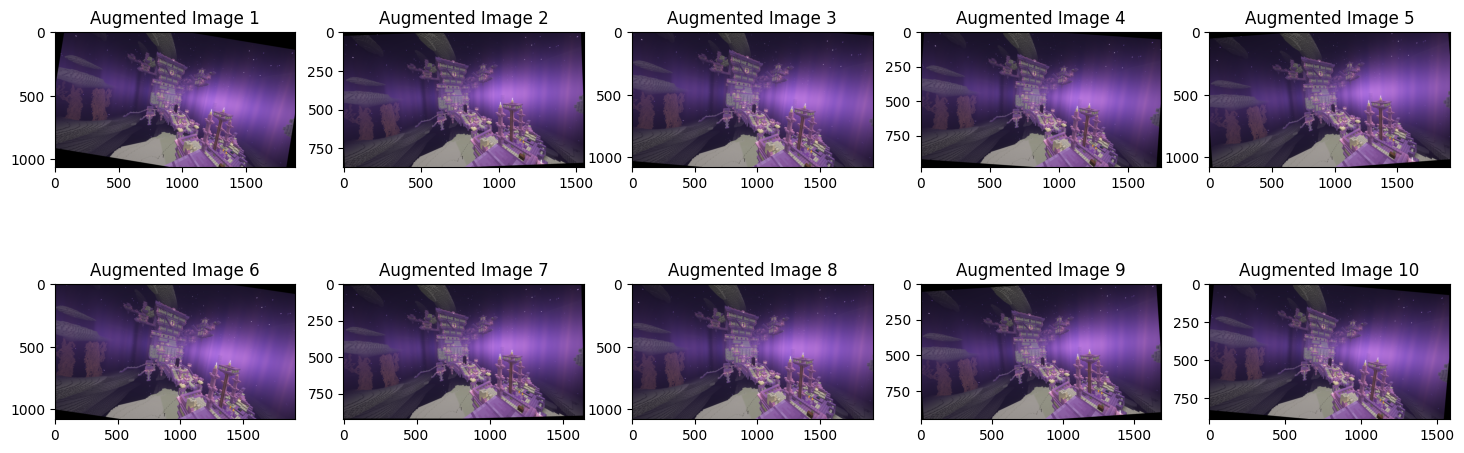

In [120]:

def randomAffineTransform(image):
    angle = rng.uniform(-10, 10) 
    scaleFactor = rng.uniform(0.8, 1.2)
    translateX = rng.randint(-10, 10) 
    translateY = rng.randint(-10, 10)

    augmentedImage = rotateImage(image, angle)
    augmentedImage = resizeImage(augmentedImage, scaleFactor, scaleFactor)
    augmentedImage = translateImage(augmentedImage, translateX, translateY)

    augmentedImage = cropCenter(augmentedImage, image.shape[1], image.shape[0])
    
    return augmentedImage

# Generate and display 10 augmented images and save augmented images
plt.figure(figsize=(18,6))
for i in range(10):
    augImg = randomAffineTransform(newImg)
    plt.subplot(2, 5, i+1)
    plt.title(f"Augmented Image {i+1}")
    plt.imshow(augImg)
    imwrite(f'augmented_image_{i+1}.png', cv2.cvtColor(augImg, cv2.COLOR_RGB2BGR))
plt.show()


    

Image Alignment (Image Registration)
   * Suppose you have two images of the same object but taken at slightly different angles.
   * Find the affine transformation matrix that aligns (registers) the two images.
   * Hint: Use the OpenCV function cv2.estimateAffinePartial2D().

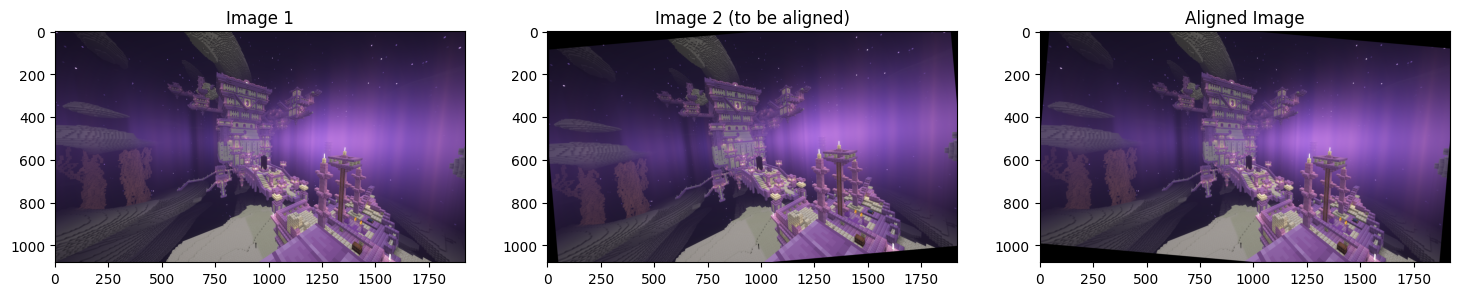

In [121]:
# Idea&source: https://www.youtube.com/watch?v=_o6fSMCmNnQ


# Assume img1 and img2 are the two images to be aligned
img1 = newImg # Original image
img2 = rotateImage(newImg, 5)  # Simulate a second image by rotating the first one slightly
img2 = translateImage(img2, 10, 5)  # And translating it slightly

# Convert images to grayscale
gray1 = cv2.cvtColor(img1, cv2.COLOR_RGB2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_RGB2GRAY)
# Detect ORB keypoints and descriptors
orb = cv2.ORB_create(500)
keypoints1, descriptors1 = orb.detectAndCompute(gray1, None)
keypoints2, descriptors2 = orb.detectAndCompute(gray2, None)
# Match features using cv2.descriptorMatcher
matcher = cv2.DescriptorMatcher_create(cv2.DESCRIPTOR_MATCHER_BRUTEFORCE_HAMMING)
matches = matcher.match(descriptors1, descriptors2, None)
# Sort matches by score
matches = sorted(matches, key=lambda x: x.distance)
# Remove not so good matches
numGoodMatches = int(len(matches) * 0.15)
matches = matches[:numGoodMatches]

# Extract location of good matches
points1 = np.zeros((len(matches), 2), dtype=np.float32)
points2 = np.zeros((len(matches), 2), dtype=np.float32)

for i, match in enumerate(matches):
    points1[i, :] = keypoints1[match.queryIdx].pt
    points2[i, :] = keypoints2[match.trainIdx].pt

# Find homography
affineMatrix, _ = cv2.estimateAffinePartial2D(points2, points1)
# Use homography to warp image
alignedImg1 = cv2.warpAffine(img2, affineMatrix, (img1.shape[1], img1.shape[0]))
# Display the results
plt.figure(figsize=(18,6))
plt.subplot(1,3,1)
plt.title("Image 1")
plt.imshow(img1)
plt.subplot(1,3,2)
plt.title("Image 2 (to be aligned)")
plt.imshow(img2)
plt.subplot(1,3,3)
plt.title("Aligned Image")
plt.imshow(alignedImg1)
plt.show()


In [122]:
# Functionize the alignment process

def imageAlignment(image1, image2):
    # Convert images to grayscale
    gray1 = cv2.cvtColor(image1, cv2.COLOR_RGB2GRAY)
    gray2 = cv2.cvtColor(image2, cv2.COLOR_RGB2GRAY)
    # Detect ORB keypoints and descriptors
    orb = cv2.ORB_create(500)
    keypoints1, descriptors1 = orb.detectAndCompute(gray1, None)
    keypoints2, descriptors2 = orb.detectAndCompute(gray2, None)
    # Match features using cv2.descriptorMatcher
    matcher = cv2.DescriptorMatcher_create(cv2.DESCRIPTOR_MATCHER_BRUTEFORCE_HAMMING)
    matches = matcher.match(descriptors1, descriptors2, None)
    # Sort matches by score
    matches = sorted(matches, key=lambda x: x.distance)
    # Remove not so good matches
    numGoodMatches = int(len(matches) * 0.15)
    matches = matches[:numGoodMatches]

    # Extract location of good matches
    points1 = np.zeros((len(matches), 2), dtype=np.float32)
    points2 = np.zeros((len(matches), 2), dtype=np.float32)

    for i, match in enumerate(matches):
        points1[i, :] = keypoints1[match.queryIdx].pt
        points2[i, :] = keypoints2[match.trainIdx].pt

    # Find affine transformation matrix
    affineMatrix, _ = cv2.estimateAffinePartial2D(points2, points1)
    
    # align image
    
    alignedImage = cv2.warpAffine(image2, affineMatrix, (image1.shape[1], image1.shape[0]))
    return alignedImage

alignedImg2 = imageAlignment(img1, img2)

## 4. Apply transformations to each color channel separately (R, G, B).
  * How do slight differences in rotation/scaling per channel affect the reconstructed RGB image?
  * Can this technique simulate color aberration seen in old cameras?

Apply transformations to each color channel separately (R, G, B)

In [ ]:
def transformEachChannel(image, angle, scaleFactor, translateX, translateY, randomOffset = None):
    if randomOffset is None:
        randomOffset = 0
    # Split the image into its color channels
    bChannel, gChannel, rChannel = cv2.split(image)
    
    # Transform each channel separately
    rChannelTransformed = rotateImage(rChannel, angle + rng.uniform(-randomOffset, randomOffset))
    rChannelTransformed = resizeImage(rChannelTransformed, scaleFactor + rng.uniform(-randomOffset/100, randomOffset/100), scaleFactor + rng.uniform(-randomOffset/100, randomOffset/100))
    rChannelTransformed = translateImage(rChannelTransformed, translateX + rng.uniform(-randomOffset/10, randomOffset/10), translateY + rng.uniform(-randomOffset/10, randomOffset/10))
    rChannelTransformed = cropCenter(rChannelTransformed, image.shape[1], image.shape[0])
    
    gChannelTransformed = rotateImage(gChannel, angle + rng.uniform(-randomOffset, randomOffset))  # Slightly different angle
    gChannelTransformed = resizeImage(gChannelTransformed, scaleFactor + rng.uniform(-randomOffset/100, randomOffset/100), scaleFactor + rng.uniform(-randomOffset/100, randomOffset/100))  # Slightly different scale
    gChannelTransformed = translateImage(gChannelTransformed, translateX + rng.uniform(-randomOffset/10, randomOffset/10), translateY + rng.uniform(-randomOffset/10, randomOffset/10))  # Slightly different translation
    gChannelTransformed = cropCenter(gChannelTransformed, image.shape[1], image.shape[0])
    
    bChannelTransformed = rotateImage(bChannel, angle + rng.uniform(-randomOffset, randomOffset))  # Slightly different angle
    bChannelTransformed = resizeImage(bChannelTransformed, scaleFactor + rng.uniform(-randomOffset/100, randomOffset/100), scaleFactor + rng.uniform(-randomOffset/100, randomOffset/100))  # Slightly different scale
    bChannelTransformed = translateImage(bChannelTransformed, translateX + rng.uniform(-randomOffset/10, randomOffset/10), translateY + rng.uniform(-randomOffset/10, randomOffset/10))  # Slightly different translation
    bChannelTransformed = cropCenter(bChannelTransformed, image.shape[1], image.shape[0])
    
    # Merge the transformed channels back into an RGB image
    transformedImage = cv2.merge((bChannelTransformed, gChannelTransformed, rChannelTransformed))
    
    return transformedImage

transformedImg = transformEachChannel(newImg, 5, 1.1, 5, 5,10)


In [124]:
#   * How do slight differences in rotation/scaling per channel affect the reconstructed RGB image?
#   * Can this technique simulate color aberration seen in old cameras?

# Answer:
# Image after applying slight differences in rotation/scaling per channel is called Chromatic Aberration (like holo effect in game?)
# Yes it can, this technique can effectively simulate color aberration seen in old cameras by adjusting each color channel to match the old camera effects (Like image shown below).


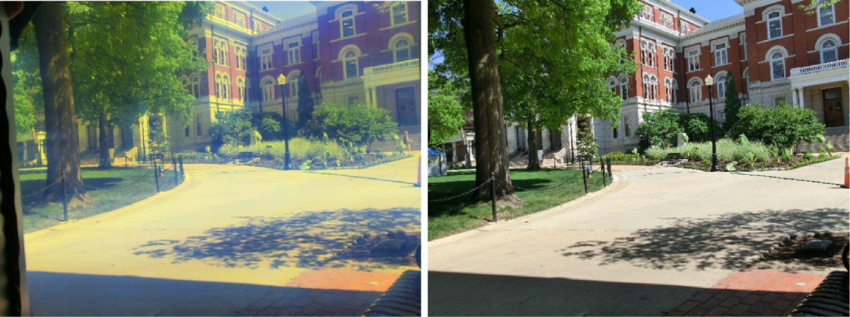

## 5.Report
  * Present the original image alongside all transformed images in a comparative layout.
  * Discuss how different transformations affect image geometry and potential implications for data augmentation or model training.

### 5.1. Present the original image alongside all transformed images in a comparative layout.

#### 5.1.1. Choose an image from the Internet

Text(0.5, 1.0, 'Original Image')

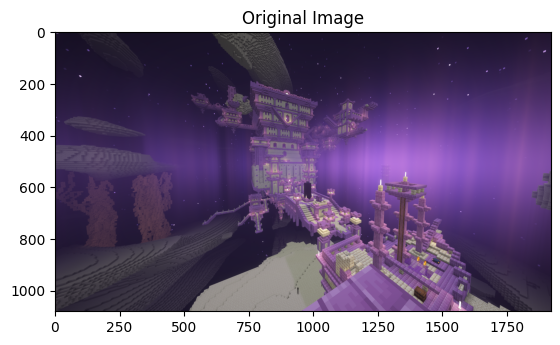

In [125]:
plt.imshow(newImg)
plt.title("Original Image")

#### 5.1.2. Transformations

Convert from brg -> rgb for image showing

Scale (resize)

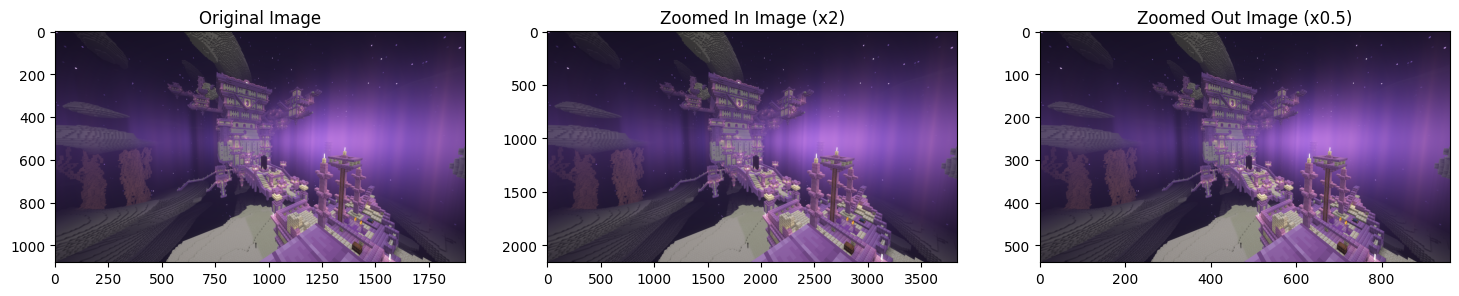

In [126]:
plt.figure(figsize=(18,6))
plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(newImg)
plt.subplot(1,3,2)
plt.title("Zoomed In Image (x2)")
plt.imshow(cv2.cvtColor(zoomedInImg, cv2.COLOR_BGR2RGB))
plt.subplot(1,3,3)
plt.title("Zoomed Out Image (x0.5)")
plt.imshow(cv2.cvtColor(zoomedOutImg, cv2.COLOR_BGR2RGB))
plt.show()


Rotate

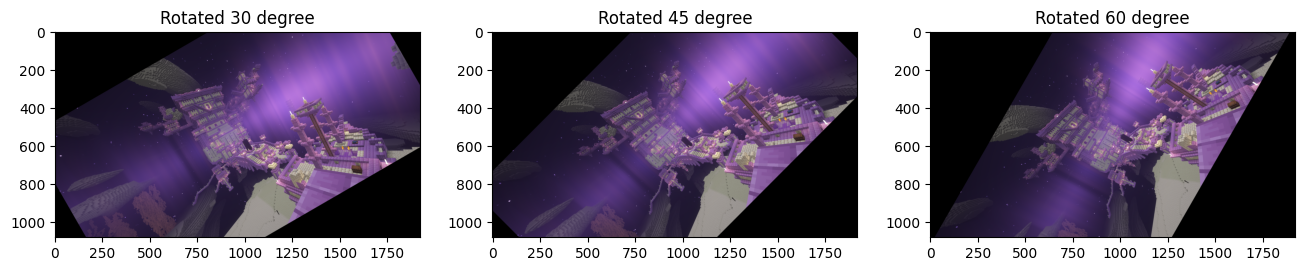

In [127]:
# Extra: rotate 60 degree with anchor point at top left corner
#rotatedImg60Anchored = rotateImage(newImg, 60, anchorPoint=(0, 0))

# Display 3 images
plt.figure(figsize=(16,8))
plt.subplot(1,3,1)
plt.title("Rotated 30 degree")
plt.imshow(cv2.cvtColor(rotatedImg30, cv2.COLOR_BGR2RGB))
plt.subplot(1,3,2)
plt.title("Rotated 45 degree")
plt.imshow(cv2.cvtColor(rotatedImg45, cv2.COLOR_BGR2RGB))
plt.subplot(1,3,3)
plt.title("Rotated 60 degree")
plt.imshow(cv2.cvtColor(rotatedImg60, cv2.COLOR_BGR2RGB))
plt.show()

Translate (shift)

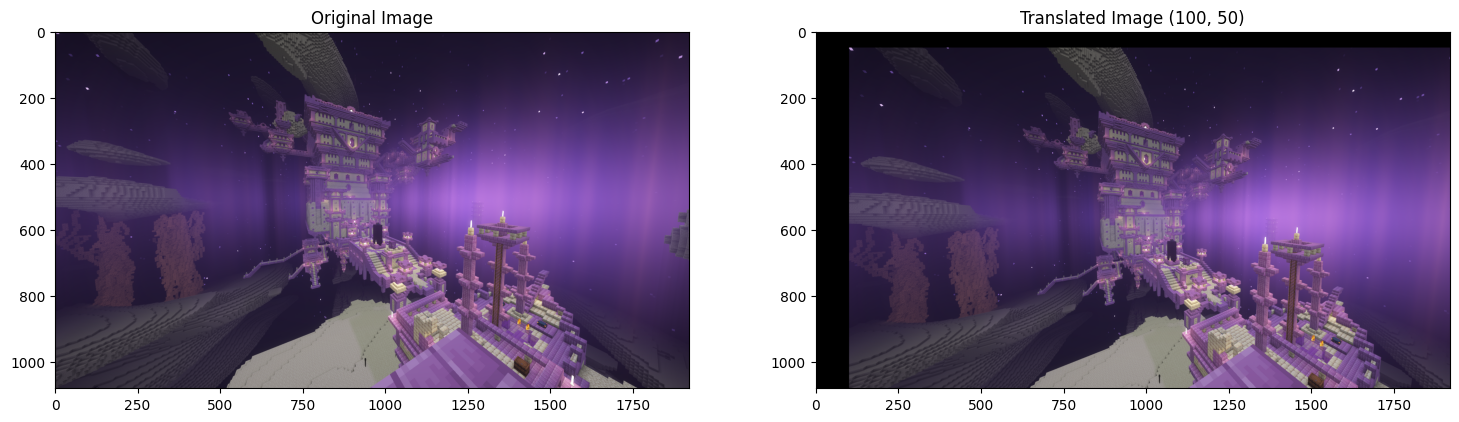

In [128]:
# original vs transplated

plt.figure(figsize=(18,6))
plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(newImg)
plt.subplot(1,2,2)
plt.title("Translated Image (100, 50)")
plt.imshow(cv2.cvtColor(translatedImg, cv2.COLOR_BGR2RGB))
plt.show()

Affine Transformation

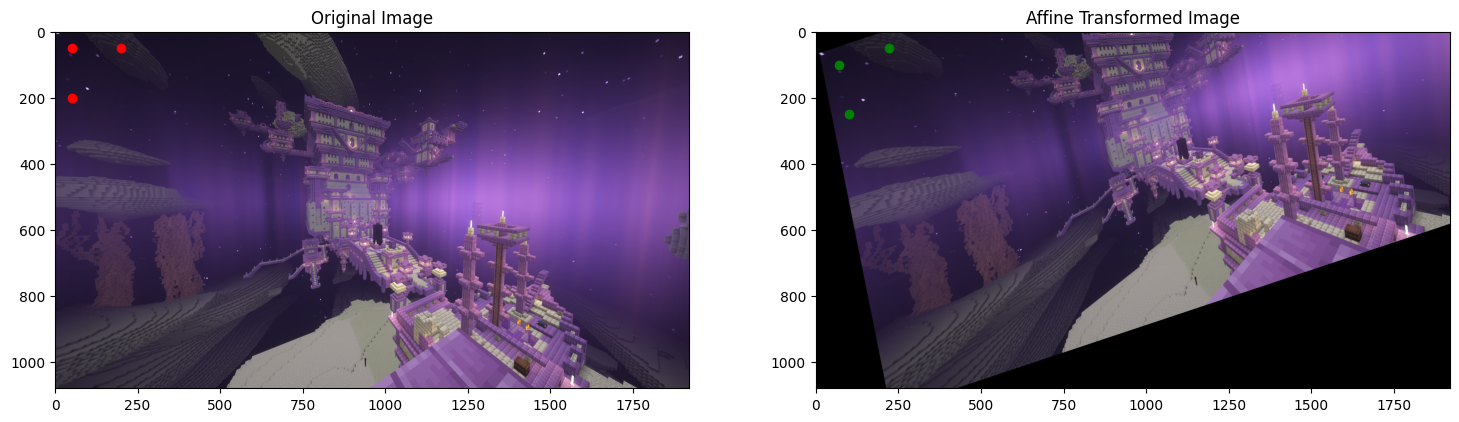

In [129]:
# Display original and affined image with points
plt.figure(figsize=(18,6))
plt.subplot(1,2,1)
plt.title("Original Image")
for pt in originalPoints:
    plt.plot(pt[0], pt[1], 'ro')  # original points (red)
plt.imshow(newImg)
plt.subplot(1,2,2)
plt.title("Affine Transformed Image")
plt.imshow(cv2.cvtColor(affinedImg, cv2.COLOR_BGR2RGB))

for pt in transformedPoints:
    plt.plot(pt[0], pt[1], 'go')  # transformed points (green)
plt.show()

Zoom with Cropping

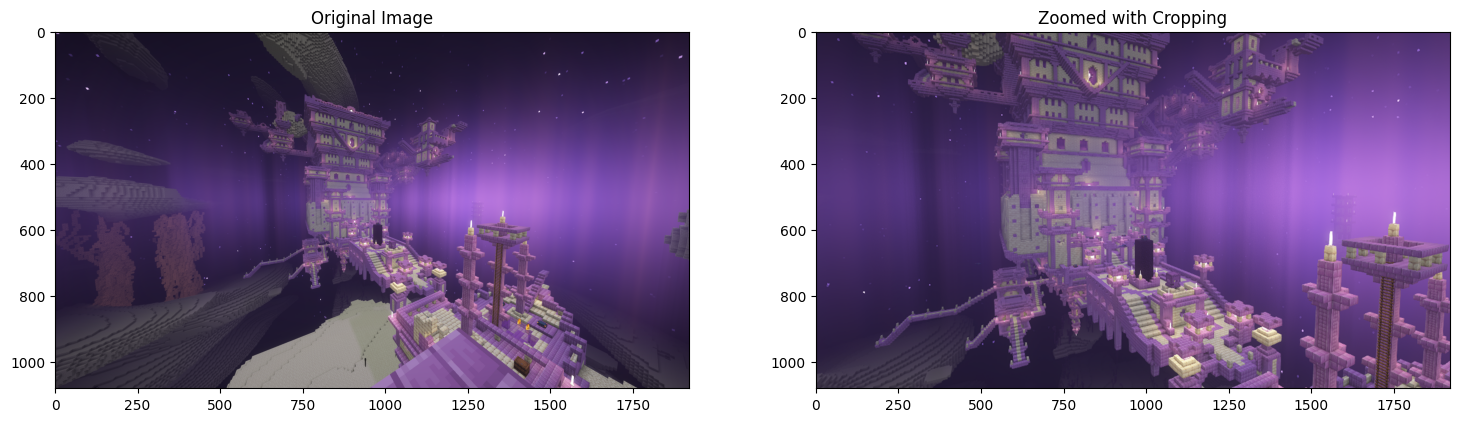

In [130]:
# show original and zoomed with cropping image
plt.figure(figsize=(18,6))
plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(newImg)
plt.subplot(1,2,2)
plt.title("Zoomed with Cropping")
plt.imshow(cv2.cvtColor(zoomedCroppedImg, cv2.COLOR_BGR2RGB))
plt.show()

#### 5.1.3. Advanced Transformations

Rotate around an arbitrary point

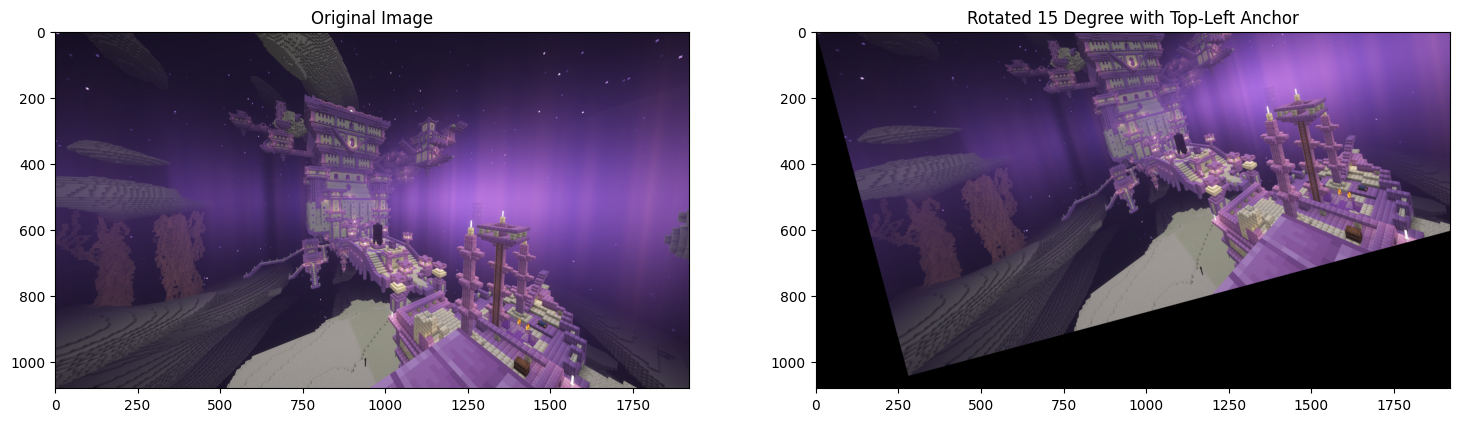

In [131]:
# show rotatedimg60Anchored vs original image
plt.figure(figsize=(18,6))
plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(newImg)
plt.subplot(1,2,2)
plt.title("Rotated 15 Degree with Top-Left Anchor")
plt.imshow(rotatedImg15Anchored)
plt.show()


Combine Translation + Rotation

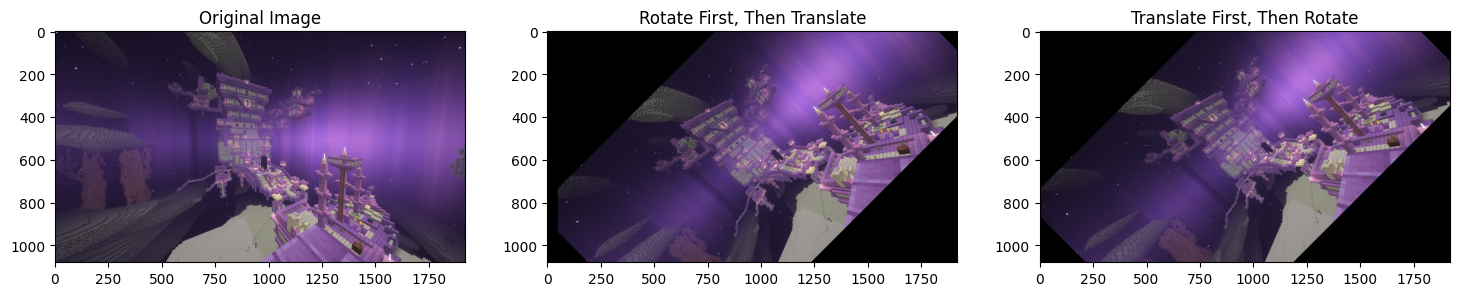

In [132]:
plt.figure(figsize=(18,6))
plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(newImg)
plt.subplot(1,3,2)
plt.title("Rotate First, Then Translate")
plt.imshow(newTestImgRT)
plt.subplot(1,3,3)
plt.title("Translate First, Then Rotate")
plt.imshow(newTestImgTR)
plt.show()

Inverse Transformation

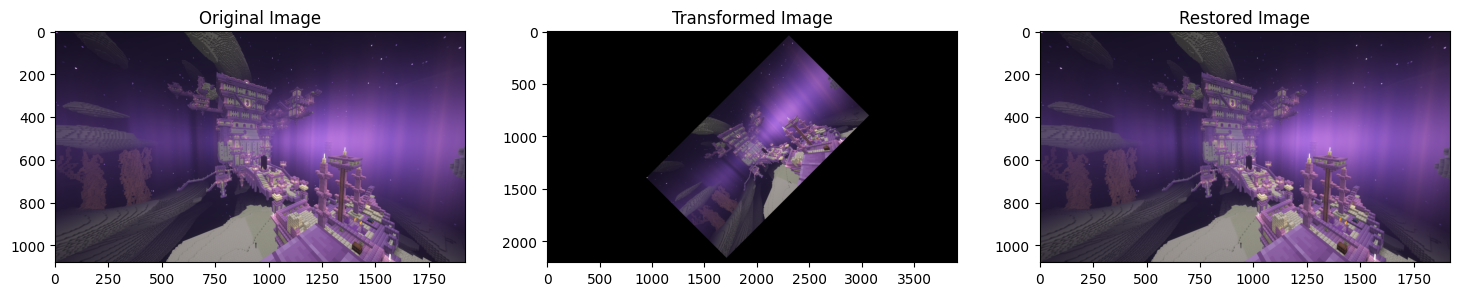

In [133]:
plt.figure(figsize=(18,6))
plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(newImg)
plt.subplot(1,3,2)
plt.title("Transformed Image")
plt.imshow(newTestImg)
plt.subplot(1,3,3)
plt.title("Restored Image")
plt.imshow(restoredImg)
plt.show()

Affine Transform for Data Augmentation

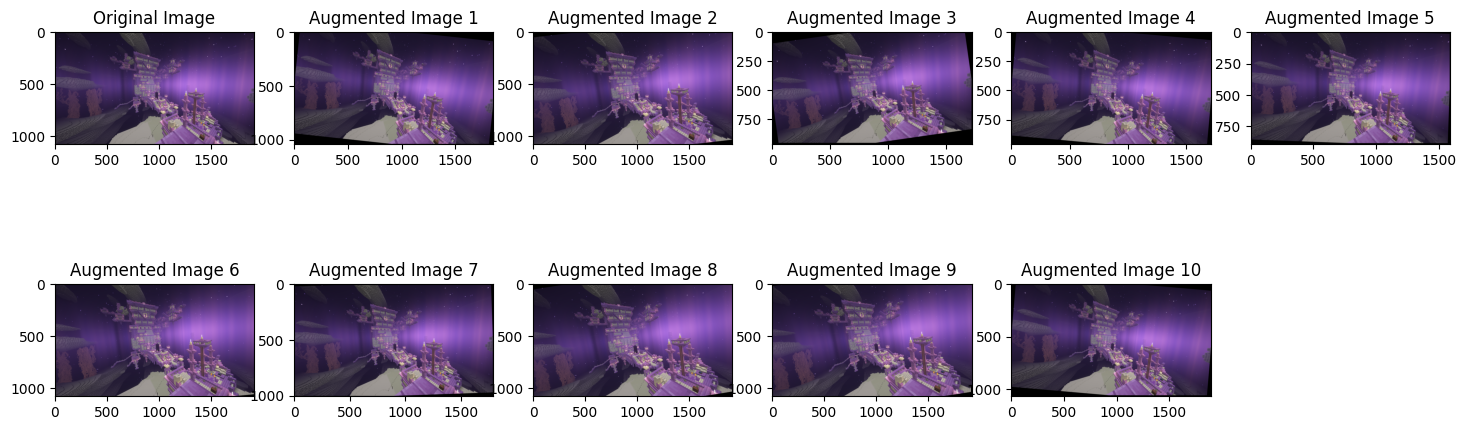

In [134]:
plt.figure(figsize=(18,6))
plt.subplot(2,6,1)
plt.title("Original Image")
plt.imshow(newImg)
for i in range(2, 12):
    augImg = randomAffineTransform(newImg)
    plt.subplot(2,6, i)
    plt.title(f"Augmented Image {i-1}")
    plt.imshow(augImg)
plt.show()



Image Alignment (Image Registration)

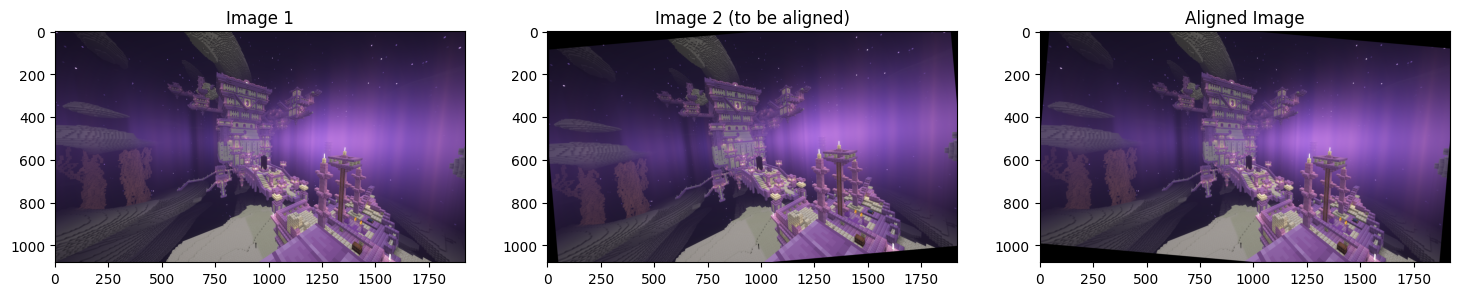

In [135]:
plt.figure(figsize=(18,6))
plt.subplot(1,3,1)
plt.title("Image 1")
plt.imshow(img1)
plt.subplot(1,3,2)
plt.title("Image 2 (to be aligned)")
plt.imshow(img2)
plt.subplot(1,3,3)
plt.title("Aligned Image")
plt.imshow(alignedImg2)
plt.show()

#### 5.1.4. Apply transformations to each color channel separately (R, G, B).

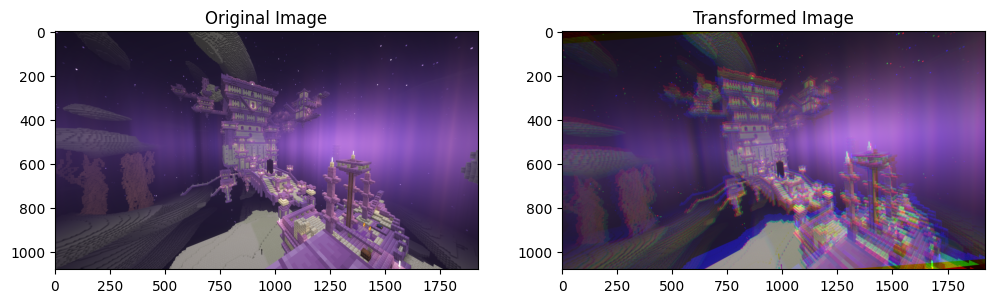

In [136]:
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.title("Original Image")
plt.imshow(newImg)
plt.subplot(1,2,2)
plt.title("Transformed Image")
plt.imshow(transformedImg)
plt.show()

### 5.2. Discuss how different transformations affect image geometry and potential implications for data augmentation or model training.


In [137]:
#Discuss how different transformations affect image geometry and potential implications for data augmentation or model training.

# Answer:
# Can be used to photoshop and modify image
# For data augmentation or model training, it can used for ocr to collect data and pattern recognition